# 03 - Feature (Hint) Distillation, FitNets-style

In the first distillation notebooks we matched a student to a teacher at the
**output** layer: the student tried to reproduce the teacher's soft logits (the
"dark knowledge" in the class probabilities). That is **logit distillation**
(Hinton et al., 2015).

This notebook adds a second, deeper kind of supervision: **feature (hint)
distillation**, introduced by FitNets (Romero et al., 2015). Instead of only
copying the teacher's final answer, the student is also asked to reproduce a
teacher **intermediate feature map** -- a "hint" taken from somewhere in the
middle of the teacher network. The student layer that learns to match it is
called the **guided layer**.

Why bother? The teacher's hidden activations encode *how* it represents the
input on the way to the answer, not just the answer. For a thin/deep student,
forcing an early-to-middle layer to look like the teacher's gives it a much
better starting representation than the output signal alone -- the gradient has
a shorter path to travel, so the deeper layers actually learn.

**The dimension problem.** The teacher's hint feature and the student's guided
feature almost never have the same shape -- different channel counts, sometimes
different spatial sizes. You cannot take an MSE between a `(B, 32, 8, 8)` teacher
tensor and a `(B, 16, 8, 8)` student tensor; the shapes do not broadcast. FitNets
solves this with a small learned **regressor** (here a 1x1 convolution) that
projects the student's feature up to the teacher's channel count, so the MSE is
well-defined. The regressor is trained jointly and thrown away at inference.

**The experiment.** We train three students of the *same tiny size* and compare
test accuracy:

1. **scratch** -- hard labels only (cross-entropy on the true digit).
2. **logit-KD** -- hard labels + KL to the teacher's softened logits.
3. **feature+logit** -- the above PLUS the FitNets hint-matching MSE.

Everything is sized to run on CPU in well under three minutes: a small data
subset, 16x16 images, tiny nets, few epochs.

## Setup and reproducibility

We import torch / torchvision / numpy / matplotlib, fix the seed to 0, force CPU,
and resolve the repo's `data/` directory by walking up from the working directory
until we find `pyproject.toml`. MNIST is already downloaded there, so
`download=True` only verifies the files are present (no network access).

In [1]:
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(0)
np.random.seed(0)
DEVICE = torch.device('cpu')

# Resolve the repo data dir regardless of where the notebook runs from.
_r = Path.cwd()
while not (_r / 'pyproject.toml').exists() and _r != _r.parent:
    _r = _r.parent
DATA_ROOT = str(_r / 'data')
print('data root:', DATA_ROOT)

data root: C:\Users\abero\dev\applied_learning\data


## Load a small MNIST subset (16x16)

Two cost-cutting moves keep this CPU-friendly:

- **Downscale to 16x16.** Fewer pixels means cheaper convolutions, and the digit
  is still legible.
- **Subset** to ~8000 train / ~2000 test images. Enough variety to separate the
  three training recipes without paying for the full 60000/10000 split.

Pixels are normalized to roughly zero-mean with the standard MNIST stats. We
build one fixed train subset and one fixed test subset (seed already pinned) so
all three students see identical data.

In [2]:
IMG_SIZE = 16
N_TRAIN = 8000
N_TEST = 2000
BATCH = 128

transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),                       # -> [0, 1], shape (1, 16, 16)
    transforms.Normalize((0.1307,), (0.3081,)),  # standard MNIST normalization
])

train_full = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=transform)
test_full = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=transform)

# Deterministic fixed subsets (global seed already set).
train_idx = torch.randperm(len(train_full))[:N_TRAIN].tolist()
test_idx = torch.randperm(len(test_full))[:N_TEST].tolist()
train_ds = Subset(train_full, train_idx)
test_ds = Subset(test_full, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

xb, yb = next(iter(train_loader))
print('train batch:', tuple(xb.shape), '| labels sample:', yb[:8].tolist())
print('train n =', len(train_ds), '| test n =', len(test_ds))

train batch: (128, 1, 16, 16) | labels sample: [8, 1, 1, 9, 0, 0, 5, 2]
train n = 8000 | test n = 2000


## The teacher: a wider CNN that exposes a hint

The teacher is a small convolutional net, but deliberately **wider** than the
students (more channels). The key design choice for FitNets is that its
`forward` returns not just the logits but also an **intermediate feature map** --
the output of its second conv block, shape `(B, 32, 8, 8)`. That tensor is the
**hint**.

Concretely the teacher is:

```
conv(1 -> 16) -> ReLU -> pool        # 16x16 -> 8x8
conv(16 -> 32) -> ReLU               # <-- HINT taken here, (B, 32, 8, 8)
pool -> flatten -> linear -> logits  # 8x8 -> 4x4
```

We grab the hint *before* the final pooling/classifier so it still carries
spatial, mid-level structure rather than a collapsed summary.

In [3]:
class Teacher(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(32 * 4 * 4, n_classes)

    def forward(self, x):
        h = self.pool(F.relu(self.conv1(x)))   # (B, 16, 8, 8)
        feat = F.relu(self.conv2(h))           # (B, 32, 8, 8)  <-- HINT
        z = self.pool(feat)                    # (B, 32, 4, 4)
        z = z.flatten(1)
        logits = self.fc(z)
        return logits, feat

teacher = Teacher().to(DEVICE)
tp = sum(p.numel() for p in teacher.parameters())
print('teacher params: %d (~%.0fk)' % (tp, tp / 1000))

teacher params: 9930 (~10k)


## Train the teacher

A short run with hard labels is enough for the teacher to reach high accuracy on
this easy subset. We keep it brief; the point is to have a competent teacher to
distill *from*, not a state-of-the-art one.

In [4]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            logits = out[0] if isinstance(out, tuple) else out
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

opt = torch.optim.Adam(teacher.parameters(), lr=2e-3)
TEACHER_EPOCHS = 3
t0 = time.time()
for ep in range(TEACHER_EPOCHS):
    teacher.train()
    for x, y in train_loader:
        logits, _ = teacher(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
    acc = accuracy(teacher, test_loader)
    print('teacher epoch %d/%d  test_acc=%.4f  elapsed=%.1fs'
          % (ep + 1, TEACHER_EPOCHS, acc, time.time() - t0))

teacher_acc = accuracy(teacher, test_loader)
print('teacher final test acc = %.4f' % teacher_acc)
teacher.eval()
for p in teacher.parameters():
    p.requires_grad_(False)

teacher epoch 1/3  test_acc=0.8715  elapsed=2.5s


teacher epoch 2/3  test_acc=0.9210  elapsed=5.0s


teacher epoch 3/3  test_acc=0.9530  elapsed=7.5s


teacher final test acc = 0.9530


## The student: thin, and it also exposes a guided feature

All three students share the **same architecture** -- only the training loss
differs. The student is narrower than the teacher (8 channels instead of 16, then
16 instead of 32). Like the teacher, its `forward` returns both the logits and
its own intermediate feature map -- the **guided feature**, shape `(B, 16, 8, 8)`.

Note the mismatch we flagged in the intro: the teacher hint is `(B, 32, 8, 8)`
but the student's guided feature is `(B, 16, 8, 8)`. Same spatial size, different
channel count. That is exactly what the regressor will bridge.

In [5]:
class Student(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(16 * 4 * 4, n_classes)

    def forward(self, x):
        h = self.pool(F.relu(self.conv1(x)))   # (B, 8, 8, 8)
        feat = F.relu(self.conv2(h))           # (B, 16, 8, 8)  <-- guided feature
        z = self.pool(feat)                    # (B, 16, 4, 4)
        z = z.flatten(1)
        logits = self.fc(z)
        return logits, feat

_tmp = Student()
sp = sum(p.numel() for p in _tmp.parameters())
print('student params: %d (~%.0fk)' % (sp, sp / 1000))
print('student is %.2fx smaller than teacher' % (tp / sp))

student params: 3818 (~4k)
student is 2.60x smaller than teacher


## Why feature matching needs a regressor

The hint loss wants `MSE(student_feature, teacher_feature)`. But:

```
teacher hint    : (B, 32, 8, 8)
student feature : (B, 16, 8, 8)
```

These do not have the same shape, so the element-wise difference is undefined.
We insert a small learned **regressor** that maps the student feature into the
teacher's feature space:

```
regressor = Conv2d(16 -> 32, kernel_size=1)
student_proj = regressor(student_feature)   # (B, 32, 8, 8)
hint_loss = MSE(student_proj, teacher_hint)
```

A **1x1 convolution** is the natural choice: it mixes channels at every spatial
location without touching the spatial layout, so it changes only the dimension
that mismatched (channels) and leaves the 8x8 grid alone. If the spatial sizes
also differed, the regressor would additionally use stride or interpolation.

Important: the regressor is part of the **training scaffold**, not the deployed
model. It is optimized jointly with the student during distillation and then
discarded -- at inference the student runs on its own. We are not making the
student bigger; we are only giving the hint loss a shape it can compute.

## The distillation losses

We define three pieces and combine them per recipe:

- **Task loss** -- ordinary cross-entropy against the true labels. Always on.
- **Logit-KD loss** -- KL divergence between the student's and teacher's
  temperature-softened logits. Temperature `T_KD` blurs the distributions so the
  student sees the teacher's relative confidences across *all* classes (the dark
  knowledge), scaled by `T_KD**2` as in Hinton et al.
- **Hint loss** -- MSE between the regressor-projected student feature and the
  teacher hint (the FitNets term).

The combined objective is `task + alpha*logitKD + beta*hint`, with the KD and
hint terms switched off (weight 0) for the recipes that do not use them.

In [6]:
T_KD = 4.0          # softmax temperature for logit distillation
ALPHA = 0.7         # weight on the logit-KD term
BETA = 4.0          # weight on the hint MSE (raw feature MSE is small in scale)

def logit_kd_loss(student_logits, teacher_logits, T=T_KD):
    # KL(teacher_soft || student_soft), scaled by T^2 (Hinton et al. 2015).
    s = F.log_softmax(student_logits / T, dim=1)
    t = F.softmax(teacher_logits / T, dim=1)
    return F.kl_div(s, t, reduction='batchmean') * (T * T)

def hint_loss(student_proj, teacher_hint):
    return F.mse_loss(student_proj, teacher_hint)

## One training routine, three configurations

A single function trains a fresh student under a chosen recipe. Flags
`use_logit` and `use_hint` turn the two distillation terms on or off. When hints
are on we build a regressor (`Conv2d(16 -> 32, 1)`) and optimize it alongside the
student. We re-seed before each run so the only difference between recipes is the
loss, not the weight initialization or the data order.

In [7]:
STUDENT_EPOCHS = 4

def train_student(use_logit, use_hint, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    student = Student().to(DEVICE)
    params = list(student.parameters())

    regressor = None
    if use_hint:
        # 1x1 conv: lift student's 16 channels -> teacher's 32, keep 8x8 spatial.
        regressor = nn.Conv2d(16, 32, kernel_size=1).to(DEVICE)
        params = params + list(regressor.parameters())

    opt = torch.optim.Adam(params, lr=2e-3)
    student.train()
    for ep in range(STUDENT_EPOCHS):
        for x, y in train_loader:
            s_logits, s_feat = student(x)
            loss = F.cross_entropy(s_logits, y)          # task loss (always on)

            if use_logit or use_hint:
                with torch.no_grad():
                    t_logits, t_feat = teacher(x)
                if use_logit:
                    loss = loss + ALPHA * logit_kd_loss(s_logits, t_logits)
                if use_hint:
                    s_proj = regressor(s_feat)           # (B, 32, 8, 8)
                    loss = loss + BETA * hint_loss(s_proj, t_feat)

            opt.zero_grad()
            loss.backward()
            opt.step()
    return student

## Run all three recipes

We train the three students back to back and measure each one's accuracy on the
fixed test subset. The regressor (when used) is silently dropped after
training -- `accuracy` only calls the student.

In [8]:
results = {}
t0 = time.time()

print('training: scratch (hard labels only) ...')
s_scratch = train_student(use_logit=False, use_hint=False)
results['scratch'] = accuracy(s_scratch, test_loader)

print('training: logit-KD ...')
s_logit = train_student(use_logit=True, use_hint=False)
results['logit-KD'] = accuracy(s_logit, test_loader)

print('training: feature+logit (FitNets) ...')
s_feat = train_student(use_logit=True, use_hint=True)
results['feature+logit'] = accuracy(s_feat, test_loader)

print('total student training wall time: %.1fs' % (time.time() - t0))
for k, v in results.items():
    print('  %-16s test_acc=%.4f' % (k, v))
print('  %-16s test_acc=%.4f' % ('(teacher)', teacher_acc))

training: scratch (hard labels only) ...


training: logit-KD ...


training: feature+logit (FitNets) ...


total student training wall time: 25.5s
  scratch          test_acc=0.9310
  logit-KD         test_acc=0.9350
  feature+logit    test_acc=0.9325
  (teacher)        test_acc=0.9530


## Compare: test accuracy of the three students

The bar chart puts the three same-size students side by side, with the teacher's
accuracy drawn as a dashed reference line. Read it as: how much of the gap to the
teacher does each kind of distillation signal recover, at identical student
capacity?

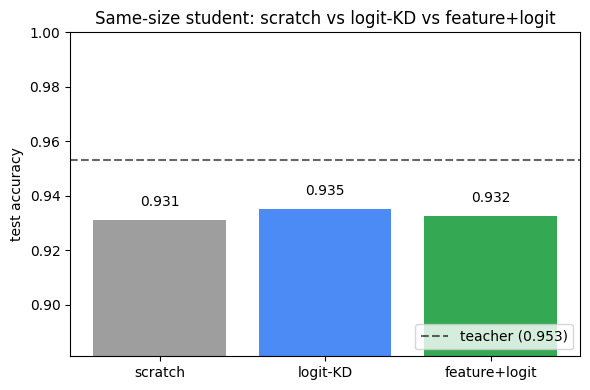

In [9]:
names = list(results.keys())
vals = [results[n] for n in names]

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#9e9e9e', '#4c8bf5', '#34a853']
bars = ax.bar(names, vals, color=colors)
ax.axhline(teacher_acc, ls='--', color='black', alpha=0.6,
           label='teacher (%.3f)' % teacher_acc)
ax.set_ylabel('test accuracy')
ax.set_title('Same-size student: scratch vs logit-KD vs feature+logit')
ax.set_ylim(min(vals) - 0.05, 1.0)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, '%.3f' % v,
            ha='center', va='bottom', fontsize=10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## When does feature distillation help over logit-only?

Both distilled students should beat scratch, and feature+logit usually edges out
logit-only -- though on a task this easy the three can land close together, and
the exact ordering varies a little run to run with such a small budget.

The intuition for *when the extra hint term pays off*:

- **Thin, deep students.** The deeper the student relative to its width, the
  harder it is for an output-only gradient to shape the early layers. A
  mid-network hint gives those layers a direct target -- this is the original
  FitNets motivation (training nets that were *deeper and thinner* than the
  teacher).
- **Big teacher/student capacity gap.** When the student cannot represent the
  teacher's full output distribution, copying just the logits asks it to mimic an
  answer it structurally cannot reach. Matching an intermediate representation is
  a softer, more learnable target.
- **Limited data.** The hint is extra supervision per example -- a dense
  `(32, 8, 8)` target instead of one label -- which regularizes the student when
  labels are scarce.

When it tends *not* to help much: when the task is easy enough that logits
already carry plenty of signal (like this 16x16 MNIST subset), when student and
teacher are nearly the same size, or when the chosen hint/guided layers are
poorly matched in abstraction level.

**Practical knobs** (all present above): *which* layer to take the hint from,
the regressor type (1x1 conv vs linear vs strided conv for spatial mismatch),
and the weight `beta`. Raw feature MSE is smaller in scale than cross-entropy, so
`beta` is set above 1 (here 4) to give the hint term real influence -- but push
it too high and the hint *overwhelms* the task loss and accuracy drops, so tuning
it is part of the craft. Modern variants (attention transfer,
FSP, review-KD) refine *what* feature signal to match, but they all inherit the
FitNets core: project to a common space, then match.

## Recap

| Recipe | Loss terms | What the student copies |
|---|---|---|
| scratch | task (CE) | nothing -- hard labels only |
| logit-KD | task + KL(soft logits) | the teacher's final answer distribution |
| feature+logit | task + KL + MSE(hint) | answer distribution **and** a mid-network feature map |

Key takeaways:

- **Hint / guided layer.** Distillation can supervise an *intermediate* feature,
  not just the output -- the teacher's hint layer guides the student's guided
  layer.
- **Regressor.** A small learned projection (a 1x1 conv here) reconciles the
  channel-count mismatch so an MSE between features is well-defined; it is part
  of the training scaffold and discarded at inference.
- **Combine, do not replace.** FitNets adds the hint term *on top of* task loss
  and (optionally) logit KD -- it is a complementary signal, not a substitute.